# 2023 Seasonal Analysis

This notebook summarizes the largest seasonal swings in the 2023 category mix and shows the ranked results in a table and bar chart.

In [1]:
import json
from pathlib import Path

import pandas as pd

path = Path('/workspace/data/database/product_data.json')
data = json.loads(path.read_text())
categories = data.get('main_categories', {})

rows = []
for category, cfg in categories.items():
    multipliers = cfg.get('washington_seasonal_multipliers')
    if not isinstance(multipliers, list):
        continue

    peak_index = max(range(len(multipliers)), key=lambda i: multipliers[i])
    low_index = min(range(len(multipliers)), key=lambda i: multipliers[i])

    peak_month = peak_index + 1
    low_month = low_index + 1
    swing = max(multipliers) - min(multipliers)

    rows.append({
        'Category': category,
        'Peak Month': peak_month,
        'Low Month': low_month,
        'Peak Multiplier': round(max(multipliers), 2),
        'Low Multiplier': round(min(multipliers), 2),
        'Swing': round(swing, 2),
    })

summary = pd.DataFrame(rows).sort_values('Swing', ascending=False).reset_index(drop=True)
summary

,Category,Peak Month,Low Month,Peak Multiplier,Low Multiplier,Swing
0,GARDEN & OUTDOOR,4,2,2.5,0.5,2.0
1,LUMBER & BUILDING MATERIALS,6,2,2.2,0.7,1.5
2,POWER TOOLS,7,12,2.1,0.8,1.3
3,PAINT & FINISHES,4,11,2.2,1.0,1.2
4,STORAGE & ORGANIZATION,12,6,1.8,0.8,1.0
5,HARDWARE,10,1,1.8,1.0,0.8
6,HAND TOOLS,5,12,1.6,0.9,0.7
7,ELECTRICAL,11,3,1.6,1.0,0.6
8,PLUMBING,10,2,1.6,1.0,0.6


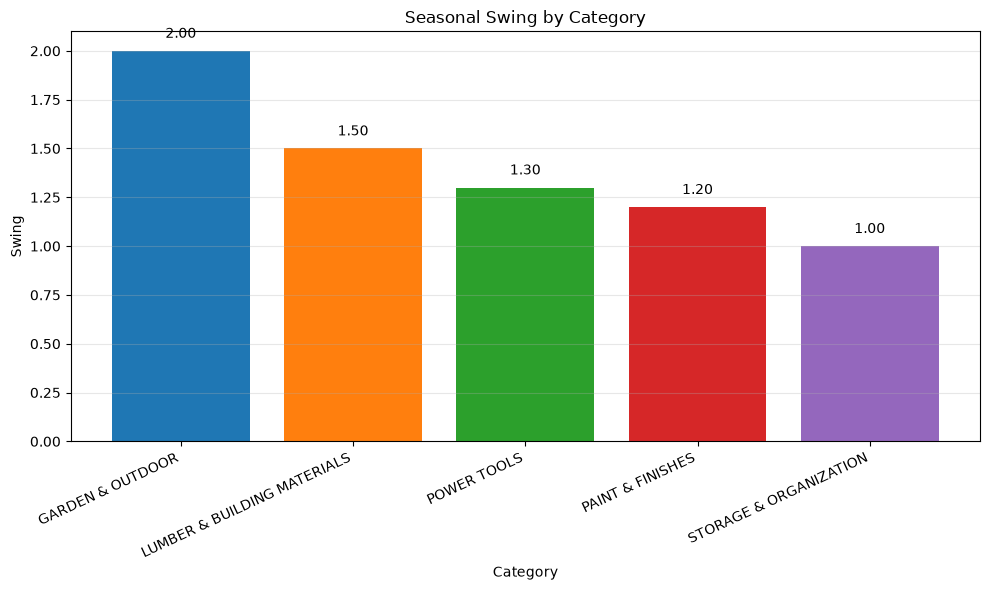

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

top = summary.head(5)
plt.figure(figsize=(10, 6))
bars = plt.bar(top['Category'], top['Swing'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Seasonal Swing by Category')
plt.xlabel('Category')
plt.ylabel('Swing')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, top['Swing']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()